# 23CSE301 Machine Learning -- Capstone Project
## Regression Track -- Data Exploration & Visualisation (Review 1, Section A)
**Dataset:** Enhanced Box Office Data (2000-2024)
**Target variable:** `$Worldwide` gross revenue

This notebook covers dataset loading, audit, and all required EDA
visualisations with insight commentary. Preprocessing, feature engineering,
and model training are covered separately in `01`-`10`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
DATA_PATH = "../data/enhanced_box_office_data_2000-2024.csv"

sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.dpi'] = 100


## A1. Dataset Loading & Audit

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print()
print("--- Data types ---")
print(df.dtypes)
print()
print("--- Missing value counts ---")
print(df.isnull().sum())
print()
print("--- Duplicate rows ---")
print("Duplicate rows:", df.duplicated().sum())
print()
print("--- Target ($Worldwide) distribution summary ---")
print(df['$Worldwide'].describe())


Shape: (5000, 13)


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America



--- Data types ---
Rank                      int64
Release Group               str
$Worldwide              float64
$Domestic               float64
Domestic %              float64
$Foreign                float64
Foreign %               float64
Year                      int64
Genres                      str
Rating                      str
Vote_Count              float64
Original_Language           str
Production_Countries        str
dtype: object

--- Missing value counts ---
Rank                      0
Release Group             0
$Worldwide                0
$Domestic                 0
Domestic %                0
$Foreign                  0
Foreign %                 0
Year                      0
Genres                  178
Rating                  170
Vote_Count              170
Original_Language       170
Production_Countries    200
dtype: int64

--- Duplicate rows ---
Duplicate rows: 0

--- Target ($Worldwide) distribution summary ---
count    5.000000e+03
mean     1.192137e+08
std    

**Observation:** The dataset contains 5,000 rows and 13 columns spanning
box-office releases from 2000-2024. Five columns (`Genres`, `Rating`,
`Vote_Count`, `Original_Language`, `Production_Countries`) contain missing
values (roughly 3-4% of rows each). No exact duplicate rows are present.

## A2 & A3. EDA Visualisations with Insight Commentary

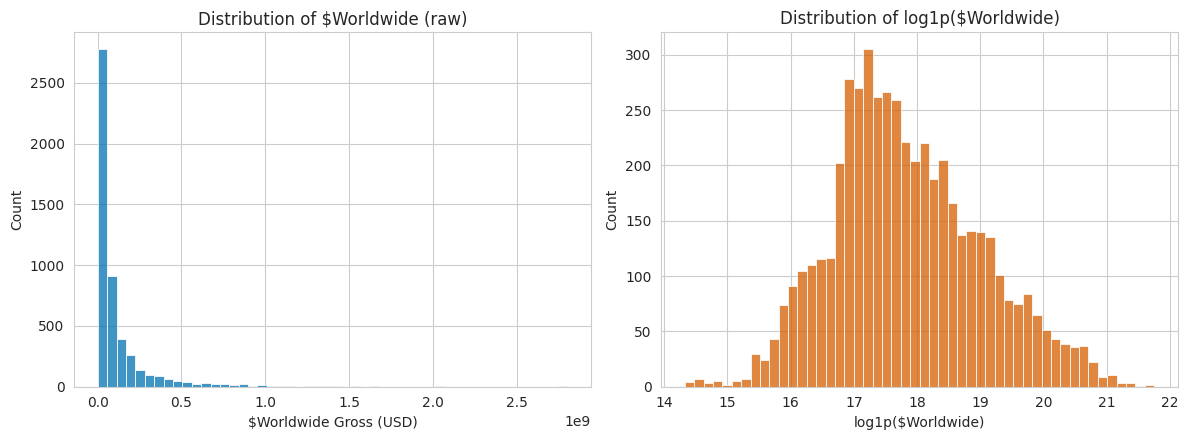

Skew (raw): 4.493
Skew (log1p): 0.338


In [3]:
# Target distribution (raw vs log-transformed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['$Worldwide'], bins=50, ax=axes[0], color='#0072B2')
axes[0].set_title('Distribution of $Worldwide (raw)')
axes[0].set_xlabel('$Worldwide Gross (USD)')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(df['$Worldwide']), bins=50, ax=axes[1], color='#D55E00')
axes[1].set_title('Distribution of log1p($Worldwide)')
axes[1].set_xlabel('log1p($Worldwide)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

print('Skew (raw):', df['$Worldwide'].skew().round(3))
print('Skew (log1p):', np.log1p(df['$Worldwide']).skew().round(3))


**Insight:** The raw target is heavily right-skewed (skew ~= 4.5), dominated
by a small number of blockbuster releases. A `log1p` transform brings the
skew down to near-symmetric (~= 0.34) -- this is why every model notebook
trains on `log1p($Worldwide)` and inverts predictions back to dollars for
evaluation.

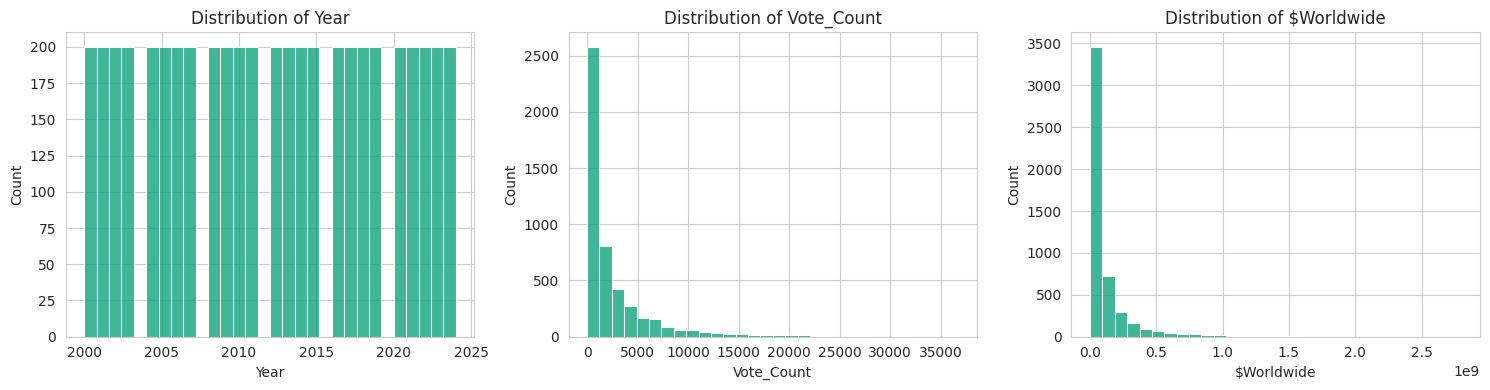

In [4]:
# Distribution plots for every numeric feature
numeric_cols = ['Year', 'Vote_Count', '$Worldwide']
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='#009E73')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()


**Insight:** `Vote_Count` is right-skewed similarly to the target (popular
releases collect disproportionately more votes). `Year` is roughly uniform,
since the dataset is a fixed top-200-per-year sample from 2000-2024.

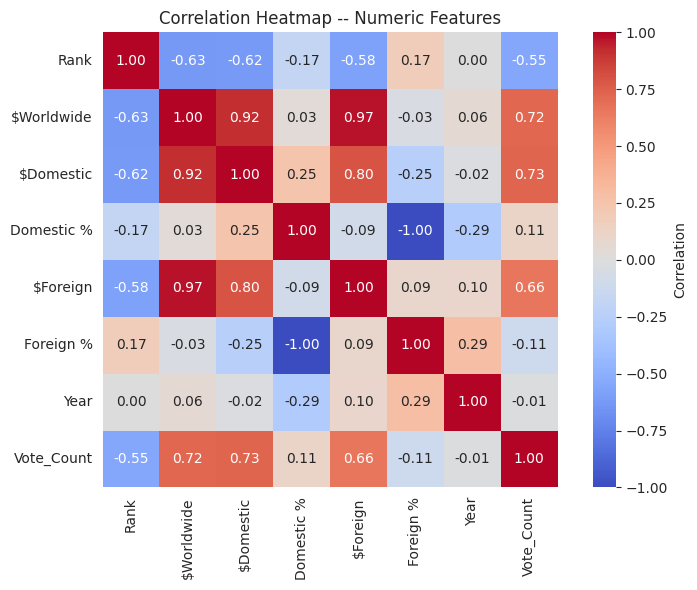

In [5]:
# Correlation heatmap (numeric columns, BEFORE dropping leakage columns)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap -- Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Insight:** `$Domestic`, `$Foreign`, `Domestic %`, `Foreign %`, and `Rank`
are all near-perfectly correlated with `$Worldwide` because they are
mathematically derived from it. These columns are dropped before modelling
in every algorithm notebook to avoid data leakage.

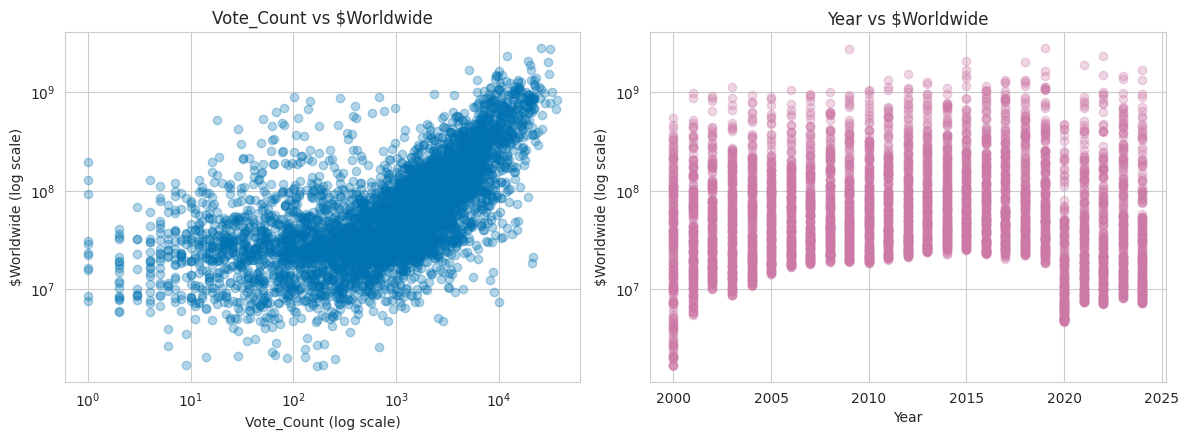

In [6]:
# Scatter plots: feature vs target relationships (>=2 required)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df['Vote_Count'], df['$Worldwide'], alpha=0.3, color='#0072B2')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Vote_Count (log scale)')
axes[0].set_ylabel('$Worldwide (log scale)')
axes[0].set_title('Vote_Count vs $Worldwide')

axes[1].scatter(df['Year'], df['$Worldwide'], alpha=0.3, color='#CC79A7')
axes[1].set_yscale('log')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('$Worldwide (log scale)')
axes[1].set_title('Year vs $Worldwide')
plt.tight_layout()
plt.savefig('scatter_feature_target.png', bbox_inches='tight')
plt.show()


**Insight:** `Vote_Count` shows a clear positive relationship with
`$Worldwide` on a log-log scale. `Year` shows no strong trend, suggesting
release year alone is a weak predictor.

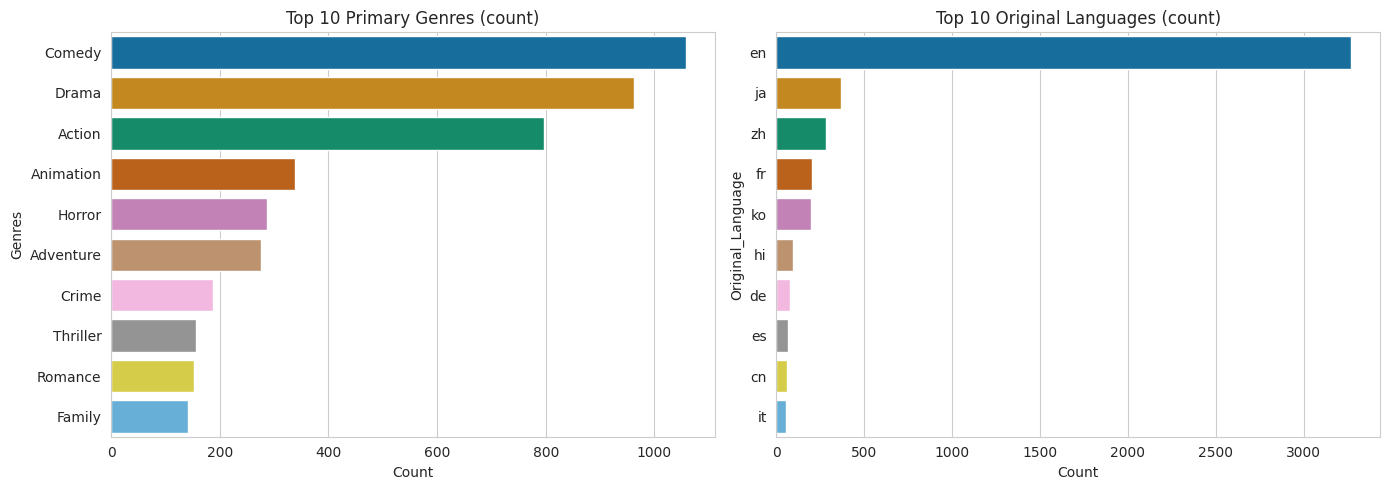

In [7]:
# Categorical feature exploration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres = df['Genres'].dropna().apply(lambda x: x.split(',')[0].strip()).value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='colorblind')
axes[0].set_title('Top 10 Primary Genres (count)')
axes[0].set_xlabel('Count')

top_langs = df['Original_Language'].value_counts().head(10)
sns.barplot(x=top_langs.values, y=top_langs.index, ax=axes[1], palette='colorblind')
axes[1].set_title('Top 10 Original Languages (count)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight')
plt.show()


**Insight:** English-language titles dominate the dataset, and Drama/Action
are among the most common primary genres -- both are important to consider
when interpreting per-category model coefficients or feature importances in
the individual algorithm notebooks.

## Summary

- Loaded and audited the Enhanced Box Office (2000-2024) dataset (5,000 rows,
  13 columns).
- Confirmed missingness pattern (5 columns, ~3-4% each) and zero duplicates.
- Identified strong right-skew in the target and the log-transform fix used
  in every model notebook.
- Identified 5 leakage-inducing columns dropped in every model notebook.
- Explored numeric distributions, correlations, feature-target relationships,
  and categorical composition.

See `01_linear_regression.ipynb` through `10_knn_regressor.ipynb` for
preprocessing, feature engineering, model training, hyperparameter tuning,
and evaluation for each of the 10 required regression algorithms.
